In [23]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import os
import requests

load_dotenv()

GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")
GITHUB_REPO  = "rahul8879/e-comm-agentic-demo"
PR_NUMBER    = 1

HEADERS = {"Authorization": f"token {GITHUB_TOKEN}", "Accept": "application/vnd.github.v3+json"}
BASE_URL = f"https://api.github.com/repos/{GITHUB_REPO}"

r = requests.get(BASE_URL, headers=HEADERS)
print(f"Repo: {r.json().get('full_name')}")
print(f"Status: {r.status_code}")

Repo: rahul8879/e-comm-agentic-demo
Status: 200


In [24]:
# pip install langgraph-checkpoint-postgres "psycopg[binary,pool]"

In [25]:
from langgraph.store.postgres import PostgresStore
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
DB_URI = os.getenv("NEON_DB_URI")

_store_cm = PostgresStore.from_conn_string(
    DB_URI,
    index ={
        "dims": 1536,
        "embed":embeddings
    }
)

store = _store_cm.__enter__()

store.setup()


In [26]:
def semantic_ns() -> tuple:
    return ("codesentinel", GITHUB_REPO, "semantic")

def procedural_ns() -> tuple:
    return ("codesentinel", GITHUB_REPO, "procedural")

def episodic_ns(author: str) -> tuple:
    return ("codesentinel", GITHUB_REPO, "episodic", author)


SEMANTIC   = semantic_ns()
PROCEDURAL = procedural_ns()

In [27]:
import uuid
rules = [
    "This repo requires parameterized SQL queries. Never build SQL with f-strings or % formatting.",
    "Passwords must be hashed with bcrypt or Argon2. MD5/SHA1 are banned.",
    "Secrets (keys, passwords) must come from environment variables, never hardcoded.",
]

for i in rules:
    store.put(SEMANTIC,str(uuid.uuid4()),{"standard": i})

In [28]:
from pathlib import Path

In [29]:
SKILLS_DIR = Path("skills")
for skill_path in sorted(SKILLS_DIR.glob("*.md")):
    store.put(PROCEDURAL, skill_path.stem, {
        "skill_name": skill_path.name,
        "content": skill_path.read_text(),
    })

## Tools

In [30]:
import base64

In [31]:
@tool
def get_pr_details() -> dict:
    """Fetch PR title, description, author, and current status."""
    r = requests.get(f"{BASE_URL}/pulls/{PR_NUMBER}", headers=HEADERS)
    pr = r.json()
    return {"title": pr.get("title"), "description": pr.get("body", ""),
            "author": pr["user"]["login"], "state": pr.get("state"),
            "branch": pr["head"]["ref"]}

@tool
def get_pr_files() -> list:
    """List all files changed in the PR with their status and patch."""
    r = requests.get(f"{BASE_URL}/pulls/{PR_NUMBER}/files", headers=HEADERS)
    return [{"filename": f.get("filename"), "status": f.get("status"),
             "changes": f.get("changes"), "patch": f.get("patch", "")[:2000]}
            for f in r.json()]

@tool
def get_file_content(file_path: str) -> str:
    """Fetch the full content of a file from the repo's default branch."""
    r = requests.get(f"{BASE_URL}/contents/{file_path}", headers=HEADERS)
    data = r.json()
    if "content" not in data:
        return f"Could not fetch: {file_path}"
    return base64.b64decode(data["content"]).decode("utf-8")

@tool
def post_pr_comment(comment: str) -> dict:
    """Post a review comment on the PR. SENSITIVE — the only action gated behind
    human approval."""
    r = requests.post(f"{BASE_URL}/issues/{PR_NUMBER}/comments", headers=HEADERS,
                       json={"body": comment})
    return {"status": r.status_code, "comment_url": r.json().get("html_url")}


In [32]:
@tool
def search_memory(kind: str, query: str, author: str = "") -> str:
    """Search CodeSentinel's long-term memory.
    kind is one of: "standards" (coding rules), "skills" (review process),
    or "author_history" (past findings for one author — pass their username)."""
    if kind == "standards":
        ns = SEMANTIC
    elif kind == "skills":
        ns = PROCEDURAL
    elif kind == "author_history":
        if not author:
            return "Provide an author username."
        ns = episodic_ns(author)
    else:
        return f"Unknown kind '{kind}'."
    hits = store.search(ns, query=query, limit=3)
    if not hits:
        return "No relevant memory found."
    return "\n".join(f"- {h.value.get('standard') or h.value.get('finding') or h.value.get('content')}"
                      for h in hits)

In [33]:
from datetime import datetime
@tool
def save_finding(author:str,finding:str):
    """Save a new, reusable finding to an author's episodic memory..."""
    store.put(episodic_ns(author),
              str(uuid.uuid4()),
              {"finding": finding,
               "author": author,
               "when": datetime.now().strftime("%Y-%m-%d"),  # for calculating the declay of informations
               
               })
    

In [34]:
tools = [get_pr_details, get_pr_files, get_file_content, post_pr_comment, search_memory, save_finding]
SENSITIVE_TOOLS = {"post_pr_comment"}   

In [35]:
from langgraph.prebuilt import ToolNode
# ToolNode: a prebuilt LangGraph node that automatically executes whichever
# tool calls the LLM requested, then returns the tool outputs as ToolMessages.

from pydantic import BaseModel, Field
# BaseModel + Field: used to define a strict schema for the final structured
# review output (so the LLM's free-text review gets converted into clean JSON).

from typing import Literal, Annotated, TypedDict
# Literal: restricts a field to a fixed set of allowed string values (e.g. verdict).
# Annotated: lets us attach extra metadata (like a reducer function) to a type hint.


class CodeReviewResult(BaseModel):
    # Pydantic schema describing the shape of the final, structured code review.
    what_looks_good: list[str] = Field(description="Positive observations")
    # List of strings capturing things the reviewer liked about the PR.
    issues_found: list[str] = Field(description="Problems found")
    # List of strings capturing problems/bugs/concerns found in the PR.
    suggestions: list[str] = Field(description="Concrete fixes")
    # List of strings with actionable suggestions to fix the issues above.
    verdict: Literal["APPROVED", "NEEDS CHANGES"] = Field(description="Final verdict")
    # Final decision, constrained to exactly one of these two string values.

class State(TypedDict):
    # Defines the shape of the graph's shared state that flows between nodes.
    messages: Annotated[list, add_messages]
    # Conversation history; `add_messages` is a reducer that appends new
    # messages to the list instead of overwriting it on each node update.
    pr_number: int
    # The pull request number being reviewed, carried through the whole run.
    verdict: str
    # Will hold the final APPROVED / NEEDS CHANGES string once review is done.
    structured_review: dict
    # Will hold the final structured review (as a plain dict) once parsed.

llm = ChatOpenAI(model="gpt-4o", temperature=0)
# Base LLM instance, temperature=0 for deterministic/consistent reasoning.

llm_with_tools = llm.bind_tools(tools)

structured_llm = ChatOpenAI(model="gpt-4o", temperature=0).with_structured_output(CodeReviewResult)


In [36]:
SYSTEM_PROMPT = """You are CodeSentinel, an expert PR code reviewer with long-term memory.
You decide which tools to call and in what order — nothing forces a sequence.
- get_pr_details / get_pr_files / get_file_content: read the PR.
- search_memory(kind, query, author): check standards, review skills, or one author's history.
- save_finding(author, finding): save a new reusable lesson. Only for genuinely new findings.
- post_pr_comment(comment): publish your review. You MUST call this for every PR you review.
When you're done investigating, write your final review as plain text covering:
what looks good, issues found, suggestions, and a verdict (APPROVED or NEEDS CHANGES),
then call post_pr_comment with that review.
"""

In [37]:
def agent_node(state: State):
    # Main "brain" node: called every time control returns to the agent.
    messages = [SystemMessage(content=SYSTEM_PROMPT)] + state["messages"]
    # Prepends the system prompt to the existing conversation history so the
    # LLM always has its instructions plus full context.
    return {"messages": [llm_with_tools.invoke(messages)]}
    # Invokes the tool-bound LLM and returns its response (an AIMessage,
    # possibly containing tool_calls) to be appended to state via add_messages.


def should_continue(state: State):
    # Routing function: decides where to go after the agent node runs.
    last = state["messages"][-1]
    # Grab the most recent message (the agent's latest output).
    if not getattr(last, "tool_calls", None):
        # If the AI message has no tool calls, it means the agent produced
        # its final plain-text review and is done investigating.
        return "finalize"
    if any(tc["name"] in SENSITIVE_TOOLS for tc in last.tool_calls):
        # If any requested tool is "sensitive" (e.g. posting a comment,
        # saving a finding), route to human review before executing.
        return "review"
    return "tools"
    # Otherwise, it's a safe/read-only tool call — execute it directly.


In [38]:
def review_tools(state: State):
    # Human-in-the-loop node: pauses execution to get human approval before
    # running sensitive tool calls.
    tool_calls = state["messages"][-1].tool_calls
    # Extract the pending tool calls that need approval.
    decision = interrupt({
        "tools": [{"name": tc["name"], "args": tc["args"]} for tc in tool_calls],
        "question": "Approve this action?",
    })
    # `interrupt` pauses the graph and surfaces this payload to a human;
    # execution resumes once a decision ("yes"/other) is supplied externally.
    if decision == "yes":
        return {}
        # Approved: no state changes needed, graph will proceed to "tools".
    rejections = [ToolMessage(content="Rejected by human reviewer. Do not repeat this exact action.",
                               tool_call_id=tc["id"]) for tc in tool_calls]
    # If rejected: build a ToolMessage per rejected call so the LLM sees a
    # tool "result" explaining the rejection instead of leaving calls unresolved.
    return {"messages": rejections}
    # These rejection messages get appended to state for the agent to react to.


In [39]:

def after_review(state: State):
    # Routing function: decides where to go after the human review step.
    last = state["messages"][-1]
    # Grab the most recent message added by review_tools.
    if isinstance(last, ToolMessage) and "Rejected" in str(last.content):
        # If it's a rejection message, send control back to the agent so it
        # can reconsider its approach instead of blindly executing.
        return "agent"
    return "tools"
    # Otherwise (approved), proceed to actually execute the tool call(s).




def finalize(state: State):
    # Final node: converts the agent's last free-text review into structured JSON.
    review_text = ""
    # Placeholder for the most recent AI-authored review text.
    for msg in reversed(state["messages"]):
        # Walk backwards through message history to find the latest AI message.
        if msg.__class__.__name__ == "AIMessage" and msg.content:
            # Check by class name (avoids needing to import AIMessage directly)
            # and ensure it actually has text content (not just tool calls).
            review_text = msg.content
            break
            # Stop at the first (most recent) matching message found.
    parsed: CodeReviewResult = structured_llm.invoke(
        f"Convert this code review into the required structured format:\n\n{review_text}"
    )
    # Ask the structured-output LLM to reshape the free text into the
    # CodeReviewResult schema (what_looks_good, issues_found, etc.).
    return {"verdict": parsed.verdict, "structured_review": parsed.model_dump()}
    # Update state: store the verdict string and the full structured review
    # (as a plain dict via model_dump()) for downstream use (e.g. posting, DB storage).



In [40]:
tool_node = ToolNode(tools)

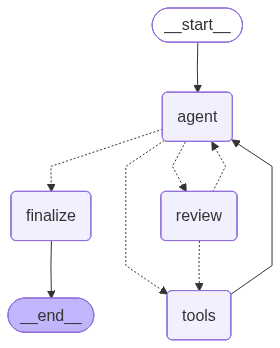

In [41]:

builder = StateGraph(State)
# Create the graph builder, typed against our State schema.

builder.add_node("agent", agent_node)
# Register the agent (LLM reasoning) node.
builder.add_node("review", review_tools)
# Register the human-in-the-loop review node.
builder.add_node("tools", tool_node)
# Register the tool-execution node.
builder.add_node("finalize", finalize)
# Register the final structured-output node.


builder.add_edge(START, "agent")
# Graph always starts by invoking the agent first.

builder.add_conditional_edges("agent", should_continue, {"review": "review", "tools": "tools", "finalize": "finalize"})
# After "agent", branch based on should_continue's return value to one of
# three possible next nodes.

builder.add_conditional_edges("review", after_review, {"agent": "agent", "tools": "tools"})
# After "review", branch based on after_review's return value: back to the
# agent (if rejected) or on to tool execution (if approved).

builder.add_edge("tools", "agent")
# After tools run, always loop back to the agent so it can process the
# tool results and decide the next step.

builder.add_edge("finalize", END)


graph = builder.compile(checkpointer=MemorySaver(), store=store)
graph

In [42]:
def print_tool_trace(result):
    print("=== Tool-call trace ===")
    for msg in result["messages"]:
        cls = msg.__class__.__name__
        if cls == "AIMessage" and getattr(msg, "tool_calls", None):
            for tc in msg.tool_calls:
                print(f"  [called] {tc['name']}({tc['args']})")
        elif cls == "ToolMessage":
            preview = str(msg.content)[:150]
            print(f"    -> {preview}{'...' if len(str(msg.content)) > 150 else ''}")
    print()


def review_pr(pr_number: int, thread_suffix: str = ""):
    """Run a full PR review. Pauses with a real input() prompt only before posting
    to GitHub. Type yes/no when asked. thread_suffix lets you re-run the same PR
    number on a fresh thread if a previous run crashed mid-way."""
    global PR_NUMBER
    PR_NUMBER = pr_number

    thread_id = f"pr-{pr_number}" + (f"-{thread_suffix}" if thread_suffix else "")
    config = {"configurable": {"thread_id": thread_id}}

    result = graph.invoke(
        {"messages": [HumanMessage(content=f"Review PR #{pr_number}")],
         "pr_number": pr_number, "verdict": "", "structured_review": {}},
        config,
    )

    while "__interrupt__" in result:
        payload = result["__interrupt__"][0].value
        print("=== APPROVAL NEEDED ===")
        for t in payload["tools"]:
            print(f"  {t['name']}({t['args']})")
        answer = input("Approve? (yes/no): ").strip().lower()
        result = graph.invoke(Command(resume=answer), config)

    print("\n=== STRUCTURED REVIEW ===")
    print(result.get("structured_review"))
    print()
    print_tool_trace(result)
    return result


In [43]:
result_1 = review_pr(10, thread_suffix="rahul_tiwari")

=== APPROVAL NEEDED ===
  post_pr_comment({'comment': 'Upon reviewing PR #10, here are my findings:\n\n### What Looks Good\n- The PR is concise and focuses on a specific change in the `orders.py` file.\n\n### Issues Found\n1. **SQL Injection Risk**: The code still constructs SQL queries using f-strings, which is highly vulnerable to SQL injection attacks. The standard practice is to use parameterized queries to prevent such vulnerabilities.\n   \n2. **Authentication Check Missing**: The comment in the code indicates that there is no authentication check, which means any user can access any order. This is a significant security risk and should be addressed by implementing proper authentication and authorization checks.\n\n3. **Hardcoded Password**: The code contains a hardcoded password in a comment. This is a security risk and should be removed immediately. Passwords should never be hardcoded in the codebase.\n\n### Suggestions\n- **Use Parameterized Queries**: Refactor the SQL query t

In [44]:
# SEMANTIC

In [45]:
("codesentinel", GITHUB_REPO, "semantic")

('codesentinel', 'rahul8879/e-comm-agentic-demo', 'semantic')

In [46]:
# prefix = codesentinel-e_commerce_demo_semantic
# key = 1
# value ={"standard ": "Repo code should follow xyz pattern"}
# prefix = codesentinel-e_commerce_demo_semantic
# key = 2
# value ={"standard ": "SQL code should not have any hard coded value"}

In [47]:
# ("codesentinel", GITHUB_REPO, "episodic", author)
# prefix = codesentinel-e_commerce_demo_episodic_rahul8879
# key = 1
# value ={"what ": "Repo code should follow xyz pattern"
#         "when ": "2023-06-01"}